<div align="left">

<h2><b>Data Collection & Preparation</b></h2>

</div>

In [ ]:
# Drive Mounting
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/London School of Economics/Deep Learning/DeepLearningProject/Code')

Mounted at /content/drive


### **Data Collection: Images and Census.**
This section draws **(i)** Google Streetview Images **(ii)** neighborhood-level (blockgroup-level) Census Data from the United States.

#### **(i) Google Street View.**
- We keep only populated and residential neighborhoods--we use Open Street Map (OSM) classification `Tag:landuse=residential`.
- We draw a income-group balanced sample (i.e., low, middle, and high income neighborhoods recieve the same number of points).
- Draws four images per location, closest built area from the provided coordiantes (0°, 90°, 180°, 270°) using Google API.

#### **(ii) Census Data.**
- Income (`B19013_001E`)
- Home Value (`B25077_001E`)
- Vacancy Share (`B25002_003E`/`B25002_001E` )
- Higher Education Share ((`B15003_022E` + `B15003_023E` + `B15003_024E` + `B15003_025E`)/`B15003_001E`)

#### **Running Directions.**
- Get Google's Street View Static API credintials. (Depending on the region Google allows for a number of free queries.)
- Get the Census API from api.census.gov/data/key_signup.html, to be inseted infront of `CENSUS_API_KEY`.
- Please make sure relative paths make sense.
- Get the following datasets from the National Historical Geographic Information System (NHGIS):
  - total population (blockgroup-level) for 2019.
  - Shapefiles 2010 (block-level) for Boston and Philly. We use 2010 as it's the most recent census year matching the 2019 identifier.
- Get the following dataset from the US Census:
  - Median income `B19013` (blockgroup-level) for 2019 for Boston and Philly.  


#### <u><strong>(i) Google Street View.</strong></u>

In [ ]:
# May need
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import os
from shapely.geometry import Point
from shapely.ops import unary_union
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyproj import Transformer
from urllib.parse import urlparse
from typing import Optional, Dict
from datetime import datetime
import requests
import re
import csv
import hmac
import time
import hashlib
import base64
import threading

# OSM setup
ox.settings.use_cache = False

#### <u><strong> Precursor functions.</strong></u>

In [ ]:
# Random points function
def random_points_in_polygon(polygon, n):
    points = []
    minx, miny, maxx, maxy = polygon.bounds
    while len(points) < n:
        p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if polygon.contains(p):
            points.append(p)
    return points

#### <u><strong> Boston: Training Set.</strong></u>

In [ ]:
# Extract total population
total_pop = pd.read_csv("../Input/nhgis0056_csv/nhgis0056_ds244_20195_blck_grp.csv")  # Source: National Historical Geographic Information System (NHGIS)
total_pop = total_pop[total_pop['STATEA'].isin([25])] # 25 = Massachusetts
total_pop = total_pop[total_pop['COUNTY'].isin(["Suffolk County"])] # Suffolk County = Boston

total_pop['GEOID'] = (total_pop['GISJOIN'].str[1:3] +
                      total_pop['GISJOIN'].str[4:7] +
                      total_pop['GISJOIN'].str[8:14] +
                      total_pop['GISJOIN'].str[14:15])
total_pop = total_pop[['GEOID', 'ALUBE001']]
total_pop.rename(columns={'ALUBE001': 'total_pop'}, inplace=True)

In [ ]:
# Filter out unpopulated areas
print(total_pop['total_pop'].quantile([0, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0]))
total_pop = total_pop[total_pop['total_pop'] >= 100]

0.00       0.00
0.01       0.00
0.02     176.80
0.05     464.75
0.10     636.50
0.25     831.25
0.50    1128.50
0.75    1531.25
1.00    4162.00
Name: total_pop, dtype: float64


In [ ]:
# Block shp files
blockgp_MA = gpd.read_file("../Input/nhgis0058_shape-nhgis0058_shapefile_tl2010_250_blck_grp_2010/MA_blck_grp_2010.shp").to_crs(epsg=3857)  # Source: NHGIS
blockgp_MA.head(5)

,STATEFP10,COUNTYFP10,TRACTCE10,BLKGRPCE10,GEOID10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,GISJOIN,Shape_area,Shape_len,geometry
0,25,023,510100,2,250235101002,Block Group 2,G5030,S,686351,0,+42.1115078,-071.0026679,G25002305101002,6.863520e+05,3343.834087,"POLYGON ((-7903527.331 5177716.672, -7903513.5..."
1,25,023,510100,3,250235101003,Block Group 3,G5030,S,403906,0,+42.1115626,-071.0105510,G25002305101003,4.039060e+05,3175.306393,"POLYGON ((-7904499.262 5177180.527, -7904527.9..."
2,25,005,631600,1,250056316001,Block Group 1,G5030,S,513645,0,+41.9387148,-071.2756925,G25000506316001,5.136486e+05,4919.057677,"POLYGON ((-7933987.349 5151683.495, -7934088.5..."
3,25,005,650202,1,250056502021,Block Group 1,G5030,S,1849612,14605,+41.6740018,-070.9355116,G25000506502021,1.864215e+06,8512.159346,"POLYGON ((-7895632.108 5112936.086, -7895618.6..."
4,25,005,650400,1,250056504001,Block Group 1,G5030,S,317515,145530,+41.6718009,-070.9193760,G25000506504001,3.175155e+05,3223.008798,"POLYGON ((-7894624.889 5111109.125, -7894655.8..."


In [ ]:
# Draw residential areas using OSM (Sources: https://wiki.openstreetmap.org/wiki/OSMnx & https://wiki.openstreetmap.org/wiki/Tag:landuse=residential)
# OSM is widely used in Economics as a datasource; I used to use this a lot as a Research Assistant.
residential_land = ox.features_from_place("Boston, Massachusetts, USA", tags={"landuse": "residential"}).to_crs(epsg=3857)
print(f"Total residential areas: {len(residential_land)}")

Total residential areas: 235


In [ ]:
# Get income per blockgroup
income_MA = pd.read_csv("../Input/ACSDT5Y2019/ACSDT5Y2019.B19013-Data.csv")  # Source: Table B19013 in the Census
income_MA = income_MA.iloc[1:] # remove descreption row
income_MA['GEOID10'] = income_MA['GEO_ID'].str[-12:]
income_MA['median_income'] = pd.to_numeric(income_MA['B19013_001E'], errors='coerce')
income_MA = income_MA.dropna(subset=['median_income'])

# Classify nb
median_national_income = 68703
low_income_ub = (2/3) * median_national_income
high_income_lb = 2 * median_national_income
income_MA["income_group"] = pd.cut(income_MA["median_income"], bins=[-np.inf, low_income_ub, high_income_lb, np.inf], labels=[0, 1, 2], include_lowest=True)

# Clean
income_MA = income_MA[['GEOID10', 'income_group', 'median_income']]
print(income_MA.tail(5))

          GEOID10 income_group  median_income
626  250251805002            1       122730.0
627  250251805003            1        61645.0
628  250251805004            1       101250.0
636  250259811004            0        44423.0
640  250259813002            1       128000.0


In [ ]:
# Keep only Boston
blockgp_MA = blockgp_MA[blockgp_MA['COUNTYFP10'].isin(["025"])] # Boston's County fip is "025"

# Extract block group GEOID
blockgp_MA['GEOID_BG'] = blockgp_MA['GEOID10'].str[:12]
before = len(blockgp_MA)

# Filter to only populated blocksgp
blockgp_MA = blockgp_MA[blockgp_MA['GEOID_BG'].isin(total_pop['GEOID'])]

# Only keep block groups intersecting with residential areas
residential_land = residential_land.geometry.union_all()
blockgp_MA = blockgp_MA[blockgp_MA.intersects(residential_land)]
blockgp_MA = blockgp_MA[['GEOID10', 'geometry']]

# Get income
blockgp_MA = blockgp_MA.merge(income_MA, on='GEOID10', how='inner')

filtered = len(blockgp_MA)

# Stats
print(f"Filtered out: {before - filtered} ({(before - filtered) / before * 100:.1f}%)")
print(blockgp_MA['income_group'].value_counts(normalize=True).sort_index())

Filtered out: 512 (79.3%)
income_group
0    0.388060
1    0.522388
2    0.089552
Name: proportion, dtype: float64


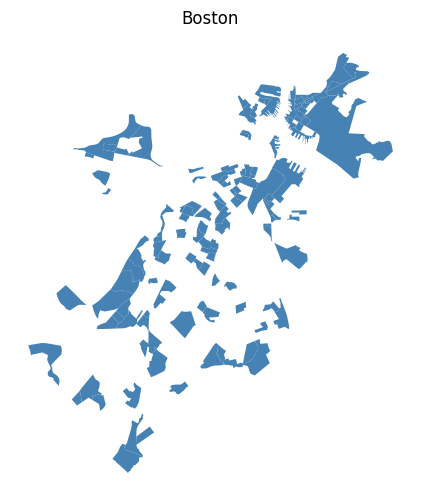

In [ ]:
# Draw Map
fig, ax = plt.subplots(figsize=(6, 6))
blockgp_MA.plot(ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Boston')
ax.set_axis_off()
plt.show()

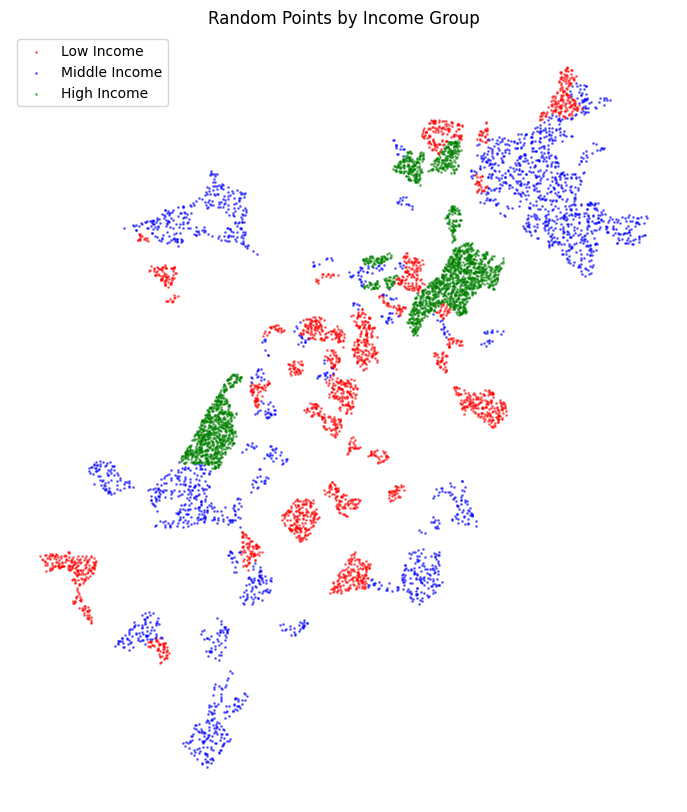

In [ ]:
# Draw income-group balanced data points
all_points = []
for group in blockgp_MA['income_group'].dropna().unique():
    subset = blockgp_MA[blockgp_MA['income_group'] == group]
    subset['weight'] = (subset.geometry.area / subset.geometry.area.sum())
    n_per_bg = (subset['weight'] * 2500).round().astype(int) # larger block groups get proportionally more points

    for _, row in subset.iterrows():
        n = n_per_bg[row.name]
        if n > 0:
            pts = random_points_in_polygon(row.geometry, n)
            for pt in pts:
                all_points.append({'geometry': pt, 'income_group': group, 'GEOID10': row['GEOID10']})

random_pts = gpd.GeoDataFrame(all_points, crs=blockgp_MA.crs)

# Plot points
fig, ax = plt.subplots(figsize=(10, 10))

colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Low Income', 1: 'Middle Income', 2: 'High Income'}

for group, color in colors.items():
    subset = random_pts[random_pts['income_group'] == group]
    subset.plot(ax=ax, color=color, markersize=1, alpha=0.5, label=labels[group])

ax.legend()
ax.set_axis_off()
ax.set_title('Random Points by Income Group')
plt.show()

In [ ]:
# Save
random_pts.to_csv("../Output/neighborhood_sample.csv", index=False)
random_pts.head(5)

#### <u><strong> Philadelphia: Training Set.</strong></u>

In [ ]:
# Extract total population
total_pop = pd.read_csv("../Input/nhgis0056_csv/nhgis0056_ds244_20195_blck_grp.csv")  # Source: National Historical Geographic Information System (NHGIS)
total_pop = total_pop[total_pop['STATEA'].isin([42])] # Pennsylvania = 42
total_pop = total_pop[total_pop['COUNTY'].isin(["Philadelphia County"])]

total_pop['GEOID'] = (total_pop['GISJOIN'].str[1:3] +
                      total_pop['GISJOIN'].str[4:7] +
                      total_pop['GISJOIN'].str[8:14] +
                      total_pop['GISJOIN'].str[14:15])
total_pop = total_pop[['GEOID', 'ALUBE001']]
total_pop.rename(columns={'ALUBE001': 'total_pop'}, inplace=True)

In [ ]:
# Filter out unpopulated areas
print(total_pop['total_pop'].quantile([0, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0]))
total_pop = total_pop[total_pop['total_pop'] >= 100]

0.00       0.00
0.01     182.20
0.02     340.10
0.05     444.50
0.10     549.00
0.25     775.25
0.50    1073.50
0.75    1473.00
1.00    4099.00
Name: total_pop, dtype: float64


In [ ]:
# Block shp files
blockgp_PA = gpd.read_file("../Input/nhgis0059_shape-nhgis0059_shapefile_tl2010_420_blck_grp_2010/PA_blck_grp_2010.shp").to_crs(epsg=3857)  # Source: NHGIS
blockgp_PA.head(5)

,STATEFP10,COUNTYFP10,TRACTCE10,BLKGRPCE10,GEOID10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,GISJOIN,Shape_area,Shape_len,geometry
0,42,061,951100,2,420619511002,Block Group 2,G5030,S,95428361,9786,+40.1479958,-077.8450182,G42006109511002,9.543815e+07,44371.876183,"POLYGON ((-8658590.628 4893100.458, -8658802.1..."
1,42,061,950300,4,420619503004,Block Group 4,G5030,S,1586775,85762,+40.5032881,-078.0303248,G42006109503004,1.672535e+06,8135.690195,"POLYGON ((-8685789.987 4940916.721, -8685788.9..."
2,42,061,950600,1,420619506001,Block Group 1,G5030,S,91249168,8938500,+40.4444427,-078.0590796,G42006109506001,1.001877e+08,44742.197273,"POLYGON ((-8680925.103 4932981.916, -8680907.9..."
3,42,061,950800,2,420619508002,Block Group 2,G5030,S,101369176,398092,+40.3776285,-077.9824554,G42006109508002,1.017673e+08,51790.219677,"POLYGON ((-8676047.416 4929806.101, -8675999.9..."
4,42,061,951000,1,420619510001,Block Group 1,G5030,S,84881834,144129,+40.2987301,-077.8368856,G42006109510001,8.502598e+07,42790.581101,"POLYGON ((-8653903.966 4916821.093, -8653906.3..."


In [ ]:
# Draw residential areas using OSM (Sources: https://wiki.openstreetmap.org/wiki/OSMnx & https://wiki.openstreetmap.org/wiki/Tag:landuse=residential)
# OSM is widely used in Economics as a datasource; I used to use this a lot as a Research Assistant.
residential_land = ox.features_from_place("Philadelphia, Pennsylvania, USA", tags={"landuse": "residential"}).to_crs(epsg=3857)
print(f"Total residential areas: {len(residential_land)}")

Total residential areas: 464


In [ ]:
# Get income per blockgroup
income_PA = pd.read_csv("../Input/ACSDT5Y2019_Philly/ACSDT5Y2019.B19013-Data.csv")  # Source: Table B19013 in the Census
income_PA = income_PA.iloc[1:] # remove descreption row
income_PA['GEOID10'] = income_PA['GEO_ID'].str[-12:]
income_PA['median_income'] = pd.to_numeric(income_PA['B19013_001E'], errors='coerce')
income_PA = income_PA.dropna(subset=['median_income'])

# Classify nb
median_national_income = 68703
low_income_ub = (2/3) * median_national_income
high_income_lb = 2 * median_national_income
income_PA["income_group"] = pd.cut(
    income_PA["median_income"],
    bins=[-np.inf, low_income_ub, high_income_lb, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
)

# Clean
income_PA = income_PA[['GEOID10', 'income_group', 'median_income']]
print(income_PA.tail(5))

           GEOID10 income_group  median_income
1323  421010390006            1        49508.0
1324  421010390007            0        21679.0
1325  421010390008            0        27750.0
1326  421019800001            1        70833.0
1328  421019802001            1        99375.0


In [ ]:
# Keep only Philly
blockgp_PA = blockgp_MA[blockgp_PA['COUNTYFP10'].isin(["101"])]

# Extract block group GEOID
blockgp_PA['GEOID_BG'] = blockgp_PA['GEOID10'].str[:12]
before = len(blockgp_PA)

# Filter to only populated blocksgp
blockgp_PA = blockgp_PA[blockgp_PA['GEOID_BG'].isin(total_pop['GEOID'])]

# Only keep block groups with residential areas
residential_land = residential_land.geometry.union_all()
blockgp_PA = blockgp_PA[blockgp_PA.intersects(residential_land)]
blockgp_PA = blockgp_PA[['GEOID10', 'geometry']]

# Get income
blockgp_PA = blockgp_PA.merge(income_PA, on='GEOID10', how='inner')

filtered = len(blockgp_PA)

# Stats
print(f"Filtered out: {before - filtered} ({(before - filtered) / before * 100:.1f}%)")
print(blockgp_PA['income_group'].value_counts(normalize=True).sort_index())

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Filtered out: 1132 (84.7%)
income_group
0    0.450980
1    0.534314
2    0.014706
Name: proportion, dtype: float64


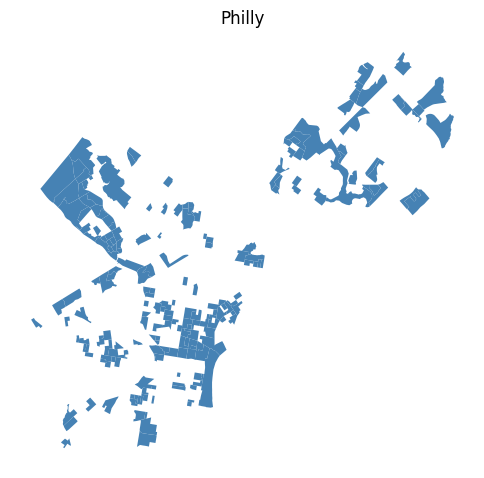

In [ ]:
# Draw Map
fig, ax = plt.subplots(figsize=(6, 6))
blockgp_PA.plot(ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Philly')
ax.set_axis_off()
plt.show()

In [ ]:
# Draw income-group balanced data points
all_points = []

for group in blockgp_PA["income_group"].dropna().unique():
    subset = blockgp_PA[blockgp_PA["income_group"] == group]
    subset["weight"] = subset.geometry.area / subset.geometry.area.sum()
    sampled_bg = subset.sample(n=25, replace=True, weights="weight", random_state=50)
    for _, row in sampled_bg.iterrows():
        pts = random_points_in_polygon(row.geometry, 1)

        for pt in pts:
            all_points.append({
                "geometry": pt,
                "income_group": group,
                "GEOID10": row["GEOID10"]
            })

random_pts = gpd.GeoDataFrame(all_points, crs=blockgp_PA.crs)

print(random_pts["income_group"].value_counts().sort_index())

income_group
0    25
1    25
2    25
Name: count, dtype: int64


In [ ]:
# Draw income-group balanced data points
all_points = []
for group in blockgp_MA['income_group'].dropna().unique():
    subset = blockgp_MA[blockgp_MA['income_group'] == group]
    subset['weight'] = (subset.geometry.area / subset.geometry.area.sum())
    n_per_bg = (subset['weight'] * 2500).round().astype(int) # larger block groups get proportionally more points

    for _, row in subset.iterrows():
        n = n_per_bg[row.name]
        if n > 0:
            pts = random_points_in_polygon(row.geometry, n)
            for pt in pts:
                all_points.append({'geometry': pt, 'income_group': group, 'GEOID10': row['GEOID10']})

random_pts = gpd.GeoDataFrame(all_points, crs=blockgp_MA.crs)

# Plot points
fig, ax = plt.subplots(figsize=(10, 10))

colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Low Income', 1: 'Middle Income', 2: 'High Income'}

for group, color in colors.items():
    subset = random_pts[random_pts['income_group'] == group]
    subset.plot(ax=ax, color=color, markersize=1, alpha=0.5, label=labels[group])

ax.legend()
ax.set_axis_off()
ax.set_title('Random Points by Income Group')
plt.show()

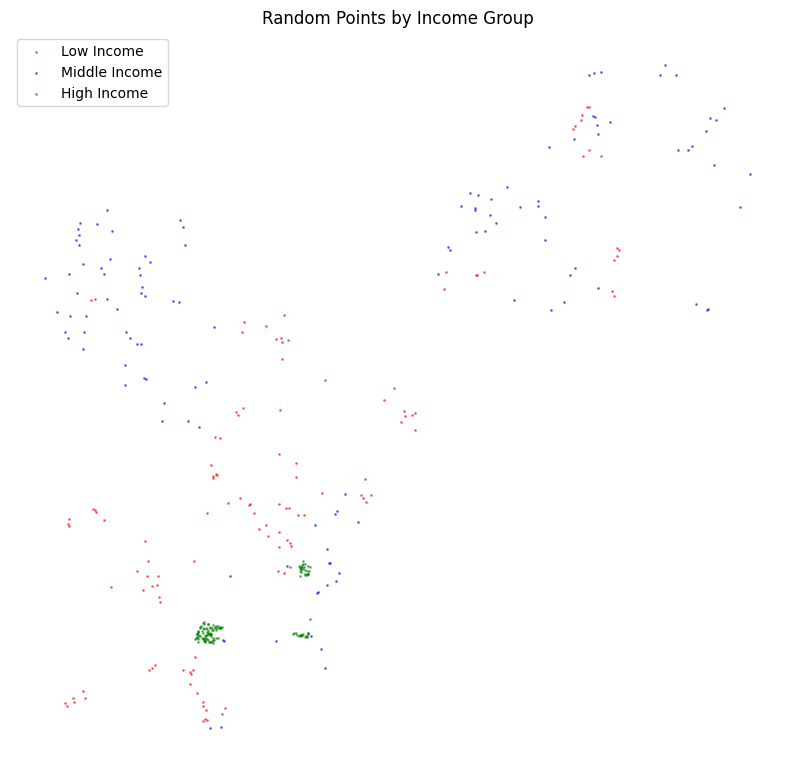

In [ ]:
# Draw income-group balanced data points
all_points = []
for group in blockgp_PA['income_group'].dropna().unique():
    subset = blockgp_PA[blockgp_PA['income_group'] == group]
    subset = subset.copy()
    subset['weight'] = subset.geometry.area / subset.geometry.area.sum()
    n_per_bg = (subset['weight'] * 2500).round().astype(int) # larger block groups get proportionally more points
    n_per_bg[n_per_bg == 0] = 1

    for _, row in subset.iterrows():
        n = n_per_bg[row.name]
        if n > 0:
            pts = random_points_in_polygon(row.geometry, n)
            for pt in pts:
                all_points.append({'geometry': pt, 'income_group': group, 'GEOID10': row['GEOID10']})

random_pts = gpd.GeoDataFrame(all_points, crs=blockgp_PA.crs)
random_pts = (random_pts.groupby("income_group", group_keys=False).sample(frac=0.05, random_state=50))

# Plot points
fig, ax = plt.subplots(figsize=(10, 10))

colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Low Income', 1: 'Middle Income', 2: 'High Income'}

for group, color in colors.items():
    subset = random_pts[random_pts['income_group'] == group]
    subset.plot(ax=ax, color=color, markersize=1, alpha=0.5, label=labels[group])

ax.legend()
ax.set_axis_off()
ax.set_title('Random Points by Income Group')
plt.show()

In [ ]:
# Save
random_pts.to_csv("../Output/neighborhood_sample_philly.csv", index=False)
print(random_pts['income_group'].value_counts(normalize=True).sort_index())
print(len(random_pts))

income_group
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
375


In [ ]:
#
# Configuration

API_KEY = "PlaceYourOwnAPIKey"
SIGNING_SECRET = "PlaceYourOwnSigningSecret"

BLOCK_GROUP_CSV = "../Output/neighborhood_sample_philly.csv"
SOURCE_CRS = "EPSG:3857"  # Change if your data uses a different CRS

IMAGE_SIZE = "640x640"
PITCH = 10
FOV = 90
SEARCH_RADIUS = 300
HEADINGS = [0, 90, 180, 270]

# Concurrency
# Each worker thread makes its own HTTP requests.
# Keep MAX_WORKERS * requests/task <= your API quota per second.
# Google Street View allows ~10 RPS on standard keys; 4–6 workers is safe.
MAX_WORKERS = 4
REQUESTS_PER_SECOND = 10  # total across all threads
DELAY = 1.0 / REQUESTS_PER_SECOND  # per-request sleep

OUTPUT_DIR = "../Input/GoogleStreetViewImagesPhilly"
METADATA_FILE = "metadata.csv"

# Coordinate conversion
_transformer = Transformer.from_crs(SOURCE_CRS, "EPSG:4326", always_xy=True)


def parse_centroid(centroid_str: str) -> tuple:
    """Parse 'POINT (-7908059.89 5217552.56)' -> (x, y) floats."""
    match = re.search(r"POINT\s*\(\s*([-\d.eE+]+)\s+([-\d.eE+]+)\s*\)", str(centroid_str))
    if match:
        return float(match.group(1)), float(match.group(2))
    raise ValueError(f"Cannot parse geometry: {centroid_str}")


def load_block_groups(csv_path: str) -> pd.DataFrame:
    """
    Load CSV, convert geometry column to lat/lng.
    Keeps GEOID10 and income_group as-is.
    Assigns a per-GEOID point index to handle multiple points per block group.
    """
    df = pd.read_csv(csv_path, dtype={"GEOID10": str, "income_group": str})

    lats, lngs = [], []
    for _, row in df.iterrows():
        x, y = parse_centroid(row["geometry"])

        # always_xy=True: input (easting=x, northing=y) -> output (lng, lat)
        lng, lat = _transformer.transform(x, y)

        # Sanity check
        if not (-90 <= lat <= 90) or not (-180 <= lng <= 180):
            raise ValueError(
                f"Bad transform for GEOID {row['GEOID10']}: "
                f"POINT({x}, {y}) -> lat={lat}, lng={lng}. "
                f"Check SOURCE_CRS (currently '{SOURCE_CRS}')."
            )

        lats.append(round(lat, 6))
        lngs.append(round(lng, 6))

    df["lat"] = lats
    df["lng"] = lngs

    # Assign per-GEOID point index (0, 1, 2, ...) to avoid filename collisions
    df["point_idx"] = df.groupby("GEOID10").cumcount()

    print(f"Loaded {len(df)} points across {df['GEOID10'].nunique()} unique block groups")
    dupes = df.groupby("GEOID10").size()
    multi = dupes[dupes > 1]
    if not multi.empty:
        print(f" GEOIDs with multiple points: {len(multi)} (max {multi.max()} points)")
    print(
        f" Sample: GEOID={df.iloc[0]['GEOID10']}, "
        f"point_idx={df.iloc[0]['point_idx']}, "
        f"income_group={df.iloc[0]['income_group']}, "
        f"lat={df.iloc[0]['lat']}, lng={df.iloc[0]['lng']}"
    )
    return df


# URL signing

def sign_url(input_url: str, secret: str) -> str:
    if not secret:
        return input_url
    decoded_key = base64.urlsafe_b64decode(secret)
    url = urlparse(input_url)
    url_to_sign = url.path + "?" + url.query
    sig = hmac.new(decoded_key, url_to_sign.encode("utf-8"), hashlib.sha1)
    encoded_sig = base64.urlsafe_b64encode(sig.digest()).decode("utf-8")
    return f"{input_url}&signature={encoded_sig}"


# Street View functions

def get_pano_metadata(lat: float, lng: float) -> Optional[Dict]:
    url = (
        f"https://maps.googleapis.com/maps/api/streetview/metadata"
        f"?location={lat},{lng}"
        f"&radius={SEARCH_RADIUS}"
        f"&source=outdoor"
        f"&key={API_KEY}"
    )
    if SIGNING_SECRET:
        url = sign_url(url, SIGNING_SECRET)
    try:
        resp = requests.get(url, timeout=10)
        time.sleep(DELAY)
        data = resp.json()
        if data.get("status") == "OK":
            return {
                "pano_id": data["pano_id"],
                "pano_lat": data["location"]["lat"],
                "pano_lng": data["location"]["lng"],
                "date": data.get("date", "unknown"),
            }
    except requests.RequestException as e:
        print(f" Warning: Metadata request failed: {e}")
    return None


def download_streetview(pano_id: str, heading: float, filepath: str) -> bool:
    url = (
        f"https://maps.googleapis.com/maps/api/streetview"
        f"?size={IMAGE_SIZE}"
        f"&pano={pano_id}"
        f"&heading={heading}"
        f"&pitch={PITCH}"
        f"&fov={FOV}"
        f"&key={API_KEY}"
    )
    if SIGNING_SECRET:
        url = sign_url(url, SIGNING_SECRET)
    try:
        resp = requests.get(url, timeout=15)
        time.sleep(DELAY)
        if resp.status_code == 200 and "image" in resp.headers.get("Content-Type", ""):
            with open(filepath, "wb") as f:
                f.write(resp.content)
            return True
    except requests.RequestException as e:
        print(f" Warning: Download failed: {e}")
    return False


# Per-row worker (runs in a thread)

def process_row(
    row_num: int,
    total: int,
    row: pd.Series,
    img_dir: str,
    existing_files: set,
    seen_panos: set,
    seen_panos_lock: threading.Lock,
    writer: csv.DictWriter,
    writer_lock: threading.Lock,
    csv_file,
    stats: dict,
    stats_lock: threading.Lock,
) -> None:
    """
    Processes a single row: fetches panorama metadata, then downloads
    all heading images. Thread-safe via locks on shared state.
    """
    geoid = str(row["GEOID10"])
    point_idx = int(row["point_idx"])
    income_group = str(row["income_group"])
    lat = row["lat"]
    lng = row["lng"]

    print(
        f"\n[{row_num}/{total}] GEOID: {geoid} pt={point_idx} "
        f"income_group: {income_group} ({lat}, {lng})"
    )

    meta = get_pano_metadata(lat, lng)
    if not meta:
        print(f" No coverage -- skipping")
        with stats_lock:
            stats["no_coverage"] += 1
        return

    pano_id = meta["pano_id"]

    # Thread-safe duplicate panorama check
    with seen_panos_lock:
        if pano_id in seen_panos:
            print(f" Duplicate panorama {pano_id} -- skipping")
            stats["duplicate_pano"] += 1
            return
        seen_panos.add(pano_id)

    print(f" Panorama: {pano_id}, date={meta['date']}")

    for heading in HEADINGS:
        # point_idx prevents filename collisions across multiple
        # geometry points sharing the same GEOID10
        filename = f"{geoid}_p{point_idx}_h{heading}.jpg"
        filepath = os.path.join(img_dir, filename)

        if filename in existing_files or os.path.exists(filepath):
            print(f" h={heading} already exists, skipping")
            with stats_lock:
                stats["skipped"] += 1
            continue

        if download_streetview(pano_id, heading, filepath):
            print(f" h={heading} downloaded")
            with stats_lock:
                stats["downloaded"] += 1

            # Thread-safe CSV write
            with writer_lock:
                writer.writerow({
                    "geoid10": geoid,
                    "point_idx": point_idx,
                    "income_group": income_group,
                    "centroid_lat": lat,
                    "centroid_lng": lng,
                    "pano_id": pano_id,
                    "pano_lat": meta["pano_lat"],
                    "pano_lng": meta["pano_lng"],
                    "heading": heading,
                    "pitch": PITCH,
                    "fov": FOV,
                    "capture_date": meta["date"],
                    "filename": filename,
                    "image_size": IMAGE_SIZE,
                })
                csv_file.flush()
        else:
            print(f" h={heading} failed")


# Main pipeline

def run_pipeline(df: pd.DataFrame):
    img_dir = os.path.join(OUTPUT_DIR, "images")
    os.makedirs(img_dir, exist_ok=True)
    metadata_path = os.path.join(OUTPUT_DIR, METADATA_FILE)

    fieldnames = [
        "geoid10", "point_idx", "income_group",
        "centroid_lat", "centroid_lng",
        "pano_id", "pano_lat", "pano_lng",
        "heading", "pitch", "fov",
        "capture_date", "filename", "image_size",
    ]

    file_exists = os.path.exists(metadata_path)
    csv_file = open(metadata_path, "a", newline="")
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    # Resume support
    existing_files = set()
    if file_exists:
        try:
            existing_df = pd.read_csv(metadata_path)
            existing_files = set(existing_df["filename"].tolist())
            print(f"Resume mode: {len(existing_files)} images already downloaded")
        except Exception:
            pass

    # Shared mutable state -- protected by locks
    seen_panos = set()
    seen_panos_lock = threading.Lock()
    writer_lock = threading.Lock()
    stats_lock = threading.Lock()
    stats = {
        "total": len(df),
        "downloaded": 0,
        "skipped": 0,
        "no_coverage": 0,
        "duplicate_pano": 0,
    }

    print(f"\n{'='*60}")
    print(f"Street View Block Group Extractor (threads={MAX_WORKERS})")
    print(f" Points total: {len(df)}")
    print(f" Unique GEOIDs: {df['GEOID10'].nunique()}")
    print(f" Headings: {HEADINGS}")
    print(f" Search radius: {SEARCH_RADIUS}m")
    print(f" Output: ./{OUTPUT_DIR}/")
    print(f"{'='*60}")

    start_time = datetime.now()

    rows = [(row_num, row) for row_num, (_, row) in enumerate(df.iterrows(), start=1)]

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(
                process_row,
                row_num, len(df), row,
                img_dir, existing_files,
                seen_panos, seen_panos_lock,
                writer, writer_lock, csv_file,
                stats, stats_lock,
            ): row_num
            for row_num, row in rows
        }

        for future in as_completed(futures):
            row_num = futures[future]
            try:
                future.result()
            except Exception as exc:
                print(f" Row {row_num} raised an exception: {exc}")

    csv_file.close()

    elapsed = (datetime.now() - start_time).total_seconds()
    print(f"\n\n{'='*60}")
    print(f"SUMMARY")
    print(f"{'='*60}")
    print(f" Total points: {stats['total']}")
    print(f" Unique GEOIDs: {df['GEOID10'].nunique()}")
    print(f" Images downloaded: {stats['downloaded']}")
    print(f" Skipped (already had): {stats['skipped']}")
    print(f" No coverage: {stats['no_coverage']}")
    print(f" Duplicate panoramas: {stats['duplicate_pano']}")
    print(f" Unique panoramas used: {len(seen_panos)}")
    print(f" Threads used: {MAX_WORKERS}")
    print(f" Time elapsed: {elapsed:.0f}s")
    print(f"\nDone!")


# Entry point

if __name__ == "__main__":
    if API_KEY == "YOUR_API_KEY":
        print("Set your API_KEY before running.")
        exit(1)

    df = load_block_groups(BLOCK_GROUP_CSV)
    run_pipeline(df)

Loaded 375 points across 117 unique block groups
 GEOIDs with multiple points: 65 (max 79 points)
 Sample: GEOID=421010152002, point_idx=0, income_group=0, lat=39.98488, lng=-75.168155

Street View Block Group Extractor (threads=4)
 Points total: 375
 Unique GEOIDs: 117
 Headings: [0, 90, 180, 270]
 Search radius: 300m
 Output: ./../Input/GoogleStreetViewImagesPhilly/

[1/375] GEOID: 421010152002 pt=0 income_group: 0 (39.98488, -75.168155)

[2/375] GEOID: 421010149006 pt=0 income_group: 0 (39.98187, -75.186497)

[3/375] GEOID: 421010064003 pt=0 income_group: 0 (39.924673, -75.238765)

[4/375] GEOID: 421010169021 pt=0 income_group: 0 (39.994526, -75.182472)
 Panorama: 8nB72wFACqdcF48QhYVCdw, date=2025-04
 Panorama: ax2LWN-wCPy4FCniQCTcaA, date=2024-04
 Panorama: 0HJwEv_MKDeFXON8HnIK6A, date=2025-05
 Panorama: XO1nI97VPWl4yh4uSGV87A, date=2025-05
 h=0 downloaded
 h=0 downloaded
 h=0 downloaded
 h=0 downloaded
 h=90 downloaded
 h=90 downloaded
 h=90 downloaded
 h=90 downloaded
 h=180 down

#### <u><strong>(ii) Census Data.</strong></u>

In [ ]:
# Needed packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import requests
import random
from PIL import Image
import zipfile
import io
from shapely.geometry import Point
from shapely.ops import unary_union

# Setting up directories
OUTPUT_DIR  = "../Output"
PHOTO_DIR  = "../Input/GoogleStreetViewImagesNew.zip"
zip_path = "../Input/streetview_dataset.zip"
metadata = "streetview_dataset/metadata.csv"

# Census Query Setup
CENSUS_API_KEY = "UseYourAPI"  # get one free at api.census.gov/data/key_signup.html
YEAR = 2019
CENSUS_VARS = {
    'B19013_001E': 'median_household_income',
    'B25077_001E': 'median_home_value',
    'B25002_003E': 'vacant_units',
    'B25002_001E': 'total_units',
    'B15003_022E': 'bachelors_degree',
    'B15003_023E': 'masters_degree',
    'B15003_024E': 'prof_degree',
    'B15003_025E': 'doctorate_degree',
    'B15003_001E': 'education_universe'
}

Number of images: 23942
Here's how paths look like: GoogleStreetViewImagesNew/250250704021_p4_h270.jpg
Checking ID format: 250250704021 (# NA: 0)


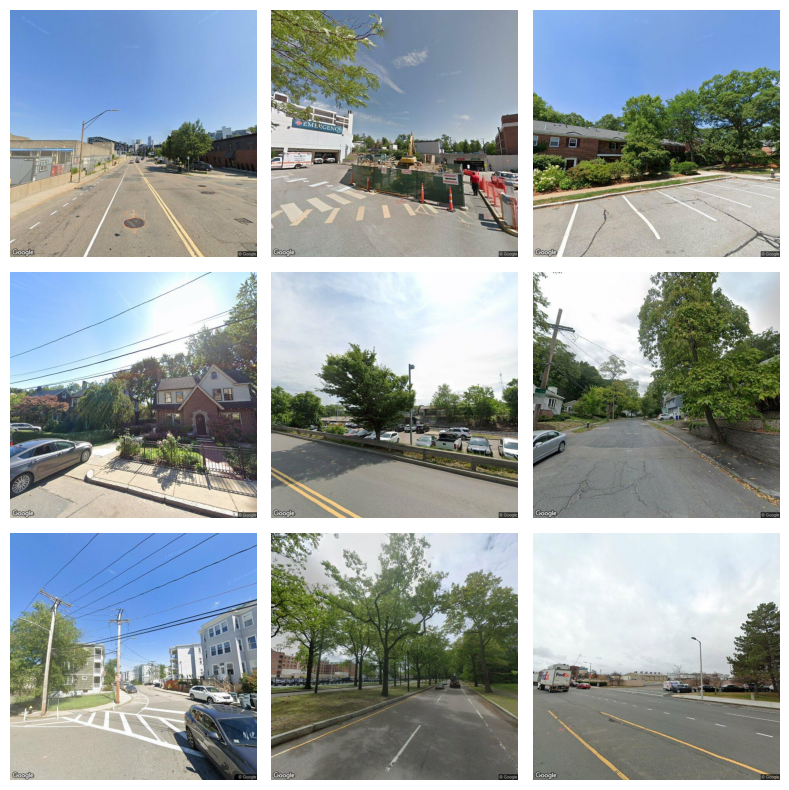

In [ ]:
# Correct GEOID issue
blockgp_MA = gpd.read_file("../Input/nhgis0058_shape-nhgis0058_shapefile_tl2010_250_blck_grp_2010/MA_blck_grp_2010.shp").to_crs(epsg=3857)

# Get GEOID from metadata
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open(metadata) as f:
        metadata = pd.read_csv(f)
metadata["geometry"] = metadata.apply(lambda row: Point(row["centroid_lng"], row["centroid_lat"]), axis=1)
metadata = gpd.GeoDataFrame(metadata, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)
metadata = metadata[["geometry", "filename"]]

# Spatial join to get GEOID10
metadata = gpd.sjoin(metadata, blockgp_MA[["GEOID10", "geometry"]], how="left", predicate="within")
metadata = metadata.drop(columns=["index_right", "geometry"])
metadata = metadata.rename(columns={"GEOID10": "GEOID"})
metadata["filename"] = metadata["filename"].apply(lambda x: x.split("/")[-1])

# Image file dataset
file_paths = []

# Read from zip file
with zipfile.ZipFile(PHOTO_DIR, "r") as zip_ref:
    for file in zip_ref.namelist():
        # Skip directories and hidden files
        if not file.endswith("/") and not os.path.basename(file).startswith("."):
            file_paths.append(file)

# Create DataFrame
images = pd.DataFrame({"file_path": file_paths})
print(f"Number of images: {len(images)}")
print(f"Here's how paths look like: {images['file_path'][0]}")

# Add neighborhood ID from metadata
images["image_name"] = images["file_path"].apply(lambda x: os.path.basename(x))
images = images.merge(metadata, left_on="image_name", right_on="filename", how="left")
images = images.drop(columns=["image_name", "filename"])
print(f"Checking ID format: {images['GEOID'].iloc[0]} (# NA: {images['GEOID'].isna().sum()})")

# Printing some photos
sample_paths = images["file_path"].sample(9)
plt.figure(figsize=(8, 8))
with zipfile.ZipFile(PHOTO_DIR, "r") as zip_ref:
    for i, path in enumerate(sample_paths):
        plt.subplot(3, 3, i + 1)
        img_data = zip_ref.read(path)
        img = Image.open(io.BytesIO(img_data))
        plt.imshow(img)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Query Census Data (Could directly use https://www.census.gov/)
# Sources used: old code of mine + https://medium.com/@mcmanus_data_works/using-the-u-s-census-bureau-api-with-python-5c30ad34dbd7

var_str = ",".join(CENSUS_VARS.keys())
st = '25' # 25 = Massachusetts

url = (f"https://api.census.gov/data/{YEAR}/acs/acs5"
       f"?get=NAME,{var_str}"
       f"&for=block%20group:*&in=state:{st}&in=county:*&in=tract:*"
       f"&key={CENSUS_API_KEY}")
r = requests.get(url)
data = r.json()
ACS = pd.DataFrame(data[1:], columns=data[0])

ACS["GEOID10"] = ACS["state"] + ACS["county"] + ACS["tract"] + ACS["block group"]
ACS = ACS.rename(columns=CENSUS_VARS)

# Convert to numeric
for col in CENSUS_VARS.values():
    ACS[col] = pd.to_numeric(ACS[col], errors="coerce")
ACS = ACS.replace(-666666666, np.nan)

# Additional Variables
ACS["vacancy_rate"] = ACS["vacant_units"]/ACS["total_units"]
ACS["shr_college"] = (ACS["bachelors_degree"] + ACS["masters_degree"] + ACS["prof_degree"]+ ACS["doctorate_degree"]) / ACS["education_universe"]

# Keep only variables we need
ACS = ACS[["GEOID10", "shr_college", "vacancy_rate",
           "median_household_income", "median_home_value"]]

print(f"ACS block groups fetched: {len(ACS):,}")

ACS block groups fetched: 4,985


In [ ]:
# Merge to Images
merged = images.merge(ACS, left_on="GEOID", right_on="GEOID10", how="left", indicator=True)
unmatched_count = (merged["_merge"] == "left_only").sum()
merged = merged.drop(columns=['GEOID10', '_merge'])
print(f"Unmatched GEOIDs: {unmatched_count}")
print(merged.head(5))

Unmatched GEOIDs: 0
                                           file_path         GEOID  \
0  GoogleStreetViewImagesNew/250250704021_p4_h270...  250250704021   
1  GoogleStreetViewImagesNew/2.50251E+11_p2082_h0...  250250606001   
2  GoogleStreetViewImagesNew/250251401071_p11_h27...  250251401071   
3  GoogleStreetViewImagesNew/250251304022_p0_h90.jpg  250251304022   
4  GoogleStreetViewImagesNew/2.50251E+11_p227_h90...  250250803001   

   shr_college  vacancy_rate  median_household_income  median_home_value  
0     0.435749      0.131763                  36333.0          1016700.0  
1     0.828280      0.194453                 155379.0           669900.0  
2     0.376741      0.070000                  88625.0           417900.0  
3     0.635036      0.000000                  40086.0           344900.0  
4     0.306796      0.060021                  42617.0           287900.0  


In [ ]:
# Balancing income dataset
images_bra = merged.copy()

# Income
median_national_income = 68703
low_income_ub = (2/3) * median_national_income
high_income_lb = 2 * median_national_income
images_bra["income_group"] = pd.cut(
    images_bra["median_household_income"],
    bins=[-np.inf, low_income_ub, high_income_lb, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
)

# College share & vacancy rate & home value
cols = ["shr_college", "vacancy_rate", "median_home_value"]
unique_bg = merged.drop_duplicates(subset="GEOID").copy()
cutoffs = {}
for col in cols:
    cutoffs[col] = unique_bg[col].quantile([1/3, 2/3]).values

for col in cols:
    q1, q2 = cutoffs[col]
    images_bra[col + "_group"] = pd.cut(
        images_bra[col],
        bins=[-np.inf, q1, q2, np.inf],
        labels=[0, 1, 2],
        include_lowest=True
    )

# Build loc_id
images_bra["loc_id"] = images_bra["file_path"].apply(
    lambda f: f.split("/")[-1].split("_h")[0]
)

# Balance income_group at location level
loc_df = images_bra.drop_duplicates(subset="loc_id")[["loc_id", "income_group"]].dropna()
counts = loc_df["income_group"].value_counts().sort_index()
min_count = counts.min()
print(f"Before balancing (locations): {dict(counts)}")

balanced_locs = (
    loc_df
    .groupby("income_group", group_keys=False)
    .apply(lambda x: x.sample(n=min_count))
)["loc_id"].values

images_bra = images_bra[images_bra["loc_id"].isin(balanced_locs)].reset_index(drop=True)
print(images_bra['income_group'].value_counts(normalize=True).sort_index())

Before balancing (locations): {0: np.int64(2280), 1: np.int64(1826), 2: np.int64(1882)}
income_group
0    0.333029
1    0.333486
2    0.333486
Name: proportion, dtype: float64


/tmp/ipykernel_5851/1839981504.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("income_group", group_keys=False)
/tmp/ipykernel_5851/1839981504.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count))


In [ ]:
# Balancing for all variables

# Build loc_id
images_bra["loc_id"] = images_bra["file_path"].apply(
    lambda f: f.split("/")[-1].split("_h")[0]
)

balanced_datasets = {}

for var in ["income_group", "shr_college_group", "vacancy_rate_group", "median_home_value_group"]:

    # Balance variable at location level
    loc_df = (images_bra.drop_duplicates(subset="loc_id")[["loc_id", var]].dropna())

    counts = loc_df[var].value_counts().sort_index()
    min_count = counts.min()
    print(f"Before balancing (locations): {dict(counts)}")

    balanced_locs = (loc_df.groupby(var, group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=50)))["loc_id"].values

    balanced_df = (images_bra[images_bra["loc_id"].isin(balanced_locs)].reset_index(drop=True).copy())

    print(f"After balancing {var} (images):")
    print(balanced_df[var].value_counts(normalize=True).sort_index())

    balanced_datasets[var] = balanced_df


Before balancing income_group (locations): {0: np.int64(1826), 1: np.int64(1826), 2: np.int64(1826)}
After balancing income_group (images):
income_group
0    0.333029
1    0.333486
2    0.333486
Name: proportion, dtype: float64

Before balancing shr_college_group (locations): {0: np.int64(1152), 1: np.int64(1219), 2: np.int64(3107)}
After balancing shr_college_group (images):
shr_college_group
0    0.333575
1    0.332851
2    0.333575
Name: proportion, dtype: float64

Before balancing vacancy_rate_group (locations): {0: np.int64(1518), 1: np.int64(1764), 2: np.int64(2196)}
After balancing vacancy_rate_group (images):
vacancy_rate_group
0    0.333516
1    0.332967
2    0.333516
Name: proportion, dtype: float64

Before balancing median_home_value_group (locations): {0: np.int64(1512), 1: np.int64(810), 2: np.int64(2183)}
After balancing median_home_value_group (images):
median_home_value_group
0    0.333059
1    0.333471
2    0.333471
Name: proportion, dtype: float64


/tmp/ipykernel_5851/2576091760.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balanced_locs = (loc_df.groupby(var, group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=50)))["loc_id"].values
/tmp/ipykernel_5851/2576091760.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_locs = (loc_df.groupby(var, group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=50)))["loc_id"].values
/tmp/ipykernel_5851/2576091760.py:17: FutureWarning: The default of observed=False is d

In [ ]:
images_bra = balanced_datasets["income_group"]
images_bra_shr_college = balanced_datasets["shr_college_group"]
images_bra_vacancy = balanced_datasets["vacancy_rate_group"]
images_bra_home_value = balanced_datasets["median_home_value_group"]

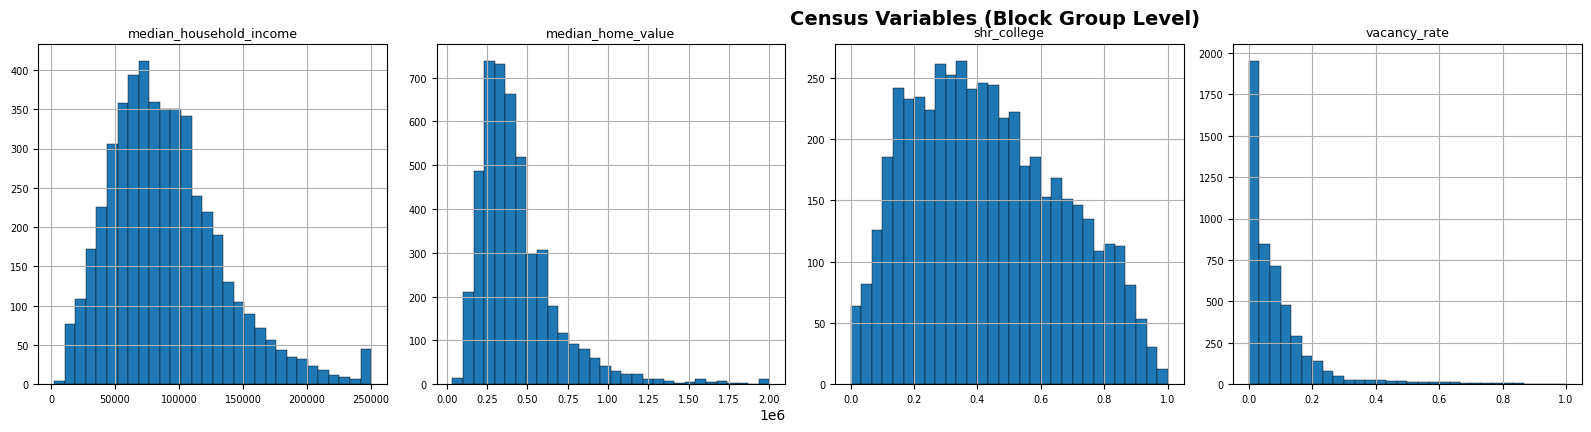

In [ ]:
cols = ["median_household_income", "median_home_value", "shr_college", "vacancy_rate"]
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    ACS[col].dropna().hist(ax=axes[i], bins=30, edgecolor="black", linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Census Variables (Block Group Level)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Saving Data
images_bra.to_csv("../Output/images_bra.csv", index=False)
images_bra_shr_college.to_csv("../Output/images_bra_shr_college.csv", index=False)
images_bra_vacancy.to_csv("../Output/images_bra_vacancy.csv", index=False)
images_bra_home_value.to_csv("../Output/images_bra_home_value.csv", index=False)